In [185]:
import switchy.CloneStats as cs
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")
sns.set_context(context='paper')
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='../'
output_suffix = ""
output_formats = [".png", ".pdf"]
output_dir='figures/9.17.20_PaperDraft/'
def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the Data

In [147]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(1350, 10) (14714, 2) shape of adata after filtering 


In [148]:
## Load the Tests
CLONE_tests = pd.read_csv('../outputs/CLONE_tests.csv', index_col = 0)
ENV_tests = pd.read_csv('../outputs/Experimental_Label_tests.csv', index_col = 0)
TREATMENT_tests = pd.read_csv('../outputs/Treatment_tests.csv', index_col = 0)

In [149]:
diffexp_treatment = pd.read_csv('output_dir/Naive.vs.Activated.csv')

In [151]:
diffexp_treatment[(diffexp_treatment.Wilcoxon < 0.01) & (diffexp_treatment.fold_change > 1)]

,Unnamed: 0,n_cells,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,Wilcoxon,fold_change
5,ENSG00000276171,219,219,0.309682,0.269784,83.813747,419.0,6.040255,False,0.287110,1.938819,-0.173901,7.047105e-04,1.299634
8,MTATP8P1,501,501,0.645972,0.498331,62.971175,874.0,6.774224,False,0.467068,0.692668,-0.938103,8.364194e-10,1.179508
16,LINC01128,278,278,15.610496,2.810035,79.453067,21121.0,9.958071,False,2.680240,6.631629,0.313857,5.526823e-11,3.583133
18,NOC2L,562,562,41.750923,3.755391,58.462676,56489.0,10.941819,True,3.942013,7.919666,1.255289,2.845932e-52,6.241388
19,KLHL17,118,118,3.762010,1.560670,91.278640,5090.0,8.535230,False,1.461659,5.868393,0.311319,6.516009e-03,2.785807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16352,MT-TY,337,337,0.361419,0.308528,75.092387,489.0,6.194406,False,0.314631,0.702270,-0.932214,3.168062e-07,1.630086
16362,MT-ND6,1327,1327,240.742050,5.487871,1.921656,325724.0,12.693809,False,5.496750,5.161709,-1.908440,2.472577e-16,1.029526
16365,MT-TP,1134,1134,57.098300,4.062137,16.186253,77254.0,11.254867,False,4.026873,5.432417,-1.344800,1.501183e-07,1.098666
16370,AL592183.1,351,351,15.979305,2.831995,74.057650,21620.0,9.981421,False,2.796701,6.330265,0.043676,2.501451e-17,3.704494


In [110]:
sigENV = list(ENV_tests[ENV_tests.corrected_pvalue < 0.01].gene)

In [111]:
sigClone = list(CLONE_tests[CLONE_tests.corrected_pvalue < 0.01].gene)

In [163]:
sigClone

['IGLC3',
 'IGLV3-21',
 'IGLC2',
 'IGKC',
 'IGKV3-20',
 'IGHV5-10-1',
 'IGLV2-14',
 'ENSG00000277048',
 'IGHV3-30',
 'CCL17',
 'SELL',
 'IGKV4-1',
 'PRDM1',
 'EBI3',
 'LMNA',
 'FCER2',
 'CD74',
 'BCL2A1',
 'SLAMF1',
 'CCL22',
 'IGHV1-69D',
 'IGHV3-23',
 'TCL1A',
 'CADM1',
 'SWAP70',
 'HOPX',
 'SMARCC1',
 'IGHV1-46',
 'ATIC',
 'IGHE',
 'UCHL1',
 'IGHV4-34',
 'IGLV1-51',
 'PIP4K2A',
 'C6orf62',
 'ANXA6',
 'HLA-DQB1',
 'CD83',
 'MYO1G',
 'IL4I1',
 'MT-RNR2',
 'ODC1',
 'IGHV3-11',
 'IGLV2-23',
 'NAPSB',
 'AHCY',
 'LETM1',
 'SGK1',
 'IGHV1-69',
 'JCHAIN',
 'IGLV1-44',
 'MS4A1',
 'RBM38',
 'FAM46C',
 'AFF3',
 'BEX3',
 'LGALS1',
 'TSPAN33',
 'MVP',
 'CHD1',
 'GABPB1-AS1',
 'IGKV3-15',
 'CFL1',
 'TMSB4X',
 'NABP1',
 'TFPI2',
 'CD44',
 'HEBP2',
 'CD38',
 'BANK1',
 'IFNGR1',
 'CPNE5',
 'PTPN6',
 'NAA50',
 'IRAK1',
 'GRHPR',
 'TNFAIP8',
 'TVP23A',
 'BCL11A',
 'HSPH1',
 'BACH2',
 'AGFG1',
 'CD86',
 'HMGA1',
 'SRSF6',
 'KYNU',
 'MIR155HG',
 'COL9A2',
 'WRNIP1',
 'MRFAP1',
 'HNRNPM',
 'ADAR',
 'STAR

In [112]:
BCell_Activation_Genes = pd.read_csv('/home/mswift/B_cells/CSR/sc_RNAseq/data_tables/metadata/mousetohumanBcellactivation_genes.csv', index_col=0)
sigAct = list(BCell_Activation_Genes.hsapGeneName)
sigDiff = list(diffexp_treatment.iloc[:,0])

In [113]:
contents = {'Experimental': sigENV, "Activation":sigDiff, 'Clonal': sigClone}

In [114]:
# UpSet Plot

In [115]:
import upsetplot as up

In [116]:
contents = up.from_contents(contents)

{'matrix': <matplotlib.axes._subplots.AxesSubplot at 0x7fa223a2fb00>,
 'shading': <matplotlib.axes._subplots.AxesSubplot at 0x7fa223a1da58>,
 'totals': <matplotlib.axes._subplots.AxesSubplot at 0x7fa223a04908>,
 'intersections': <matplotlib.axes._subplots.AxesSubplot at 0x7fa2239b95f8>}

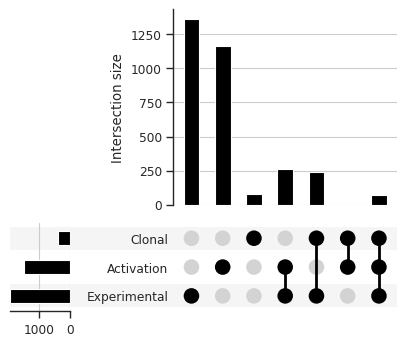

In [183]:
fig, ax = plt.subplots(1,1)
plt.axis('off')
up.plot(contents, fig = fig )

In [187]:
save_figure(fig, 'UpSet')

In [133]:
Clonal_Only = contents.xs((False, False))

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/IPython/core/interactiveshell.py:2895: PerformanceWarning: indexing past lexsort depth may impact performance.
  return runner(coro)


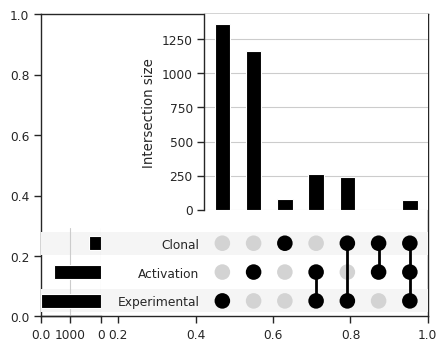

In [182]:
fig

In [134]:
nonIG_ClonalOnly.shape

(47, 1)

In [135]:
Clonal_Only.shape[0] 

81

In [136]:
Clonal_Only.shape[0] - nonIG_ClonalOnly.shape[0]

34

In [168]:
nonIG_ClonalOnly = Clonal_Only[(Clonal_Only.index == True) & (~Clonal_Only.id.str.contains('IGH|IGL|IGK'))]


AttributeError: 'list' object has no attribute 'id'

In [171]:
CLONE_tests[(~CLONE_tests.gene.str.contains('IGH|IGL|IGK')) & (CLONE_tests.corrected_pvalue < 0.01)].gene

9992    ENSG00000277048
7876              CCL17
747                SELL
3496              PRDM1
9040               EBI3
             ...       
6695             ANKLE2
4878            SMARCA2
655             SLC50A1
120              AKR7A2
6955              SCFD1
Name: gene, Length: 354, dtype: object

In [167]:
nonIG_sigClone

,id
Clonal,
True,PRDM1
True,UCHL1
True,MS4A1
True,FAM46C
True,CD38
True,ACTC1
True,ZFP57
True,CKAP4
True,CLEC2B


In [162]:
list(nonIG_ClonalOnly.id)

['PRDM1',
 'UCHL1',
 'MS4A1',
 'FAM46C',
 'CD38',
 'ACTC1',
 'ZFP57',
 'CKAP4',
 'CLEC2B',
 'HIST1H3G',
 'CABLES1',
 'PDE4D',
 'CEP128',
 'SLC7A5',
 'VEGFA',
 'PAX5',
 'CITED2',
 'IQGAP2',
 'ALOX5',
 'TCEAL7',
 'SETBP1',
 'ZFAT',
 'TRAM2',
 'SELPLG',
 'SERPINB9',
 'AHNAK',
 'E2F2',
 'COTL1',
 'MYH8',
 'CFI',
 'IFNG-AS1',
 'TP53INP1',
 'RASSF6',
 'TEX261',
 'KCNN3',
 'LDLRAP1',
 'TG',
 'AC246787.2',
 'DTX1',
 'VRK3',
 'AC023796.2',
 'AL109918.1',
 'IL13RA1',
 'HIST1H2BC',
 'KCTD10',
 'CIITA',
 'VPS35L']

In [188]:
CLONE_tests[CLONE_tests.gene == 'MYC']

,n_cells,n_counts,highly_variable,means,dispersions,dispersions_norm,score,gene,pvalue,corrected_pvalue
4816,669,228839.0,True,4.982692,6.652161,0.01495,0.0,MYC,0.000054,0.539185


In [173]:
CLONE_tests[CLONE_tests.gene.isin(nonIG_ClonalOnly.id)]

,n_cells,n_counts,highly_variable,means,dispersions,dispersions_norm,score,gene,pvalue,corrected_pvalue
3496,184,103872.0,True,4.534521,8.429470,2.034451,0.0,PRDM1,5.450439e-17,5.449894e-13
2420,78,6615.0,True,1.598875,5.194526,-0.107017,0.0,UCHL1,2.853893e-13,2.853608e-09
5431,1310,3465824.0,True,7.792882,8.471290,1.915214,0.0,MS4A1,9.177272e-12,9.176355e-08
525,316,129908.0,True,4.674635,7.968009,1.510107,0.0,FAM46C,1.183151e-11,1.183033e-07
2379,150,43750.0,True,3.421955,6.837884,0.266719,0.0,CD38,6.979474e-11,6.978776e-07
7296,127,57820.0,True,3.835708,7.432677,0.885675,0.0,ACTC1,1.049675e-09,1.049570e-05
3248,161,14796.0,True,2.383175,5.850508,-0.297057,0.0,ZFP57,5.428076e-09,5.427533e-05
6556,118,13464.0,True,2.564727,7.007147,0.744806,0.0,CKAP4,5.619327e-09,5.618765e-05
6207,478,67160.0,True,4.050361,7.357823,0.781040,0.0,CLEC2B,6.644239e-09,6.643575e-05
3206,132,3333.0,True,1.088228,4.826345,0.225909,0.0,HIST1H3G,1.024746e-08,1.024643e-04
